# Collaborative Filtering for Recommendation Systems

## Introduction to Recommendation SystemsRecommendation systems are a subclass of information filtering systems that seek to predict the "rating" or "preference" a user would give to an item. They are used in a variety of areas, with the most common examples being

There are two main types of recommendation systems:1. **Content-Based Filtering:** This method uses item features to recommend other items similar to what the user likes. For example, if a user likes a movie with a certain actor, the system will recommend other movies with that same actor.2. **Collaborative Filtering:** This method makes automatic predictions (filtering) about the interests of a user by collecting preferences or taste information from many users (collaborating). The underlying assumption is that if a person A has the same opinion as a person B on an issue, A is more likely to have B's opinion on a different issue than that of a randomly chosen person.

## Content-Based Filtering

Content-based filtering methods are based on a description of the item and a profile of the user’s preferences. In a content-based recommendation system, keywords are used to describe the items and a user profile is built to indicate the type of item this user likes. The algorithms work by comparing the user's profile with the item's features.Let's consider a simple example. We have a small dataset of movies and their genres. We will use this information to build a content-based recommendation system.

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

In [2]:
data = {'Movie': ['The Matrix', 'Inception', 'Toy Story', 'Saving Private Ryan', 'The Dark Knight'],
        'Genre': ['Action, Sci-Fi', 'Action, Sci-Fi, Thriller', 'Animation, Comedy', 'War, Drama', 'Action, Crime, Drama']}
df = pd.DataFrame(data)

We will use TF-IDF (Term Frequency-Inverse Document Frequency) to convert the genre text into a matrix of TF-IDF features.

In [3]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['Genre'])

Now, we can compute the cosine similarity between movies based on their genres.

In [4]:
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

We can now create a function that takes in a movie title as input and outputs a list of the most similar movies.

In [5]:
indices = pd.Series(df.index, index=df['Movie']).drop_duplicates()

def get_recommendations(title, cosine_sim=cosine_sim):
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]
    return df['Movie'].iloc[movie_indices]

In [6]:
get_recommendations('The Matrix')

1              Inception
4        The Dark Knight
2              Toy Story
3    Saving Private Ryan
Name: Movie, dtype: object

## Collaborative Filtering

Collaborative filtering is a technique that can filter out items that a user might like on the basis of reactions by similar users. It works by searching a large group of people and finding a smaller set of users with tastes similar to a particular user.There are two main types of collaborative filtering:1. **User-User Collaborative Filtering:** In this technique, we find users who have similar rating patterns and recommend items that they have liked.2. **Item-Item Collaborative Filtering:** In this technique, we find items that are similar to each other and recommend similar items to the user.

Let's create a simple dataset to demonstrate collaborative filtering.

In [7]:
import numpy as np
from sklearn.metrics.pairwise import pairwise_distances

In [8]:
data = {'User': ['User 1', 'User 1', 'User 2', 'User 2', 'User 3', 'User 3', 'User 4', 'User 4'],
        'Movie': ['The Matrix', 'Inception', 'The Matrix', 'Toy Story', 'Inception', 'The Dark Knight', 'Toy Story', 'Saving Private Ryan'],
        'Rating': [5, 4, 4, 3, 5, 4, 3, 5]}
df_ratings = pd.DataFrame(data)

In [9]:
ratings_matrix = df_ratings.pivot_table(index='User', columns='Movie', values='Rating').fillna(0)

### User-User Collaborative Filtering

In [10]:
user_similarity = 1 - pairwise_distances(ratings_matrix.values, metric='cosine')

### Item-Item Collaborative Filtering

In [11]:
item_similarity = 1 - pairwise_distances(ratings_matrix.T.values, metric='cosine')

Now, let's make predictions. We can predict the rating a user would give to an item they have not yet rated.

In [12]:
def predict(ratings, similarity, type='user'):
    if type == 'user':
        mean_user_rating = ratings.mean(axis=1)
        ratings_diff = (ratings - mean_user_rating[:, np.newaxis])
        pred = mean_user_rating[:, np.newaxis] + similarity.dot(ratings_diff) / np.array([np.abs(similarity).sum(axis=1)]).T
    elif type == 'item':
        pred = ratings.dot(similarity) / np.array([np.abs(similarity).sum(axis=1)])
    return pred

In [13]:
user_prediction = predict(ratings_matrix.values, user_similarity, type='user')

In [14]:
item_prediction = predict(ratings_matrix.values, item_similarity, type='item')

Now, let's create a function to get recommendations for a user.

In [15]:
def get_recommendations_for_user(user_id, ratings_matrix, user_prediction_df):
    user_ratings = ratings_matrix.loc[user_id]
    unrated_movies = user_ratings[user_ratings == 0].index
    predictions = user_prediction_df.loc[user_id, unrated_movies]
    return predictions.sort_values(ascending=False)

In [16]:
user_prediction_df = pd.DataFrame(user_prediction, index=ratings_matrix.index, columns=ratings_matrix.columns)
get_recommendations_for_user('User 1', ratings_matrix, user_prediction_df)

Movie
The Dark Knight        1.041940
Toy Story              1.005426
Saving Private Ryan    0.118285
Name: User 1, dtype: float64

## Visualizations

We can visualize the user and item similarity matrices using heatmaps.

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

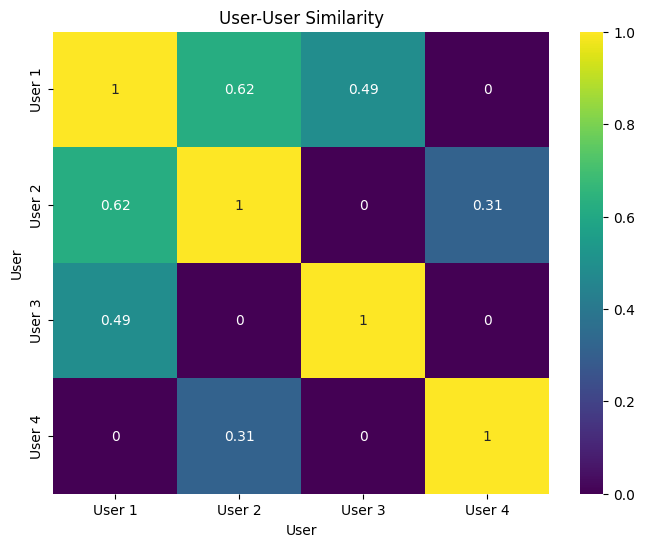

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(pd.DataFrame(user_similarity, index=ratings_matrix.index, columns=ratings_matrix.index), annot=True, cmap='viridis')
plt.title('User-User Similarity')
plt.show()

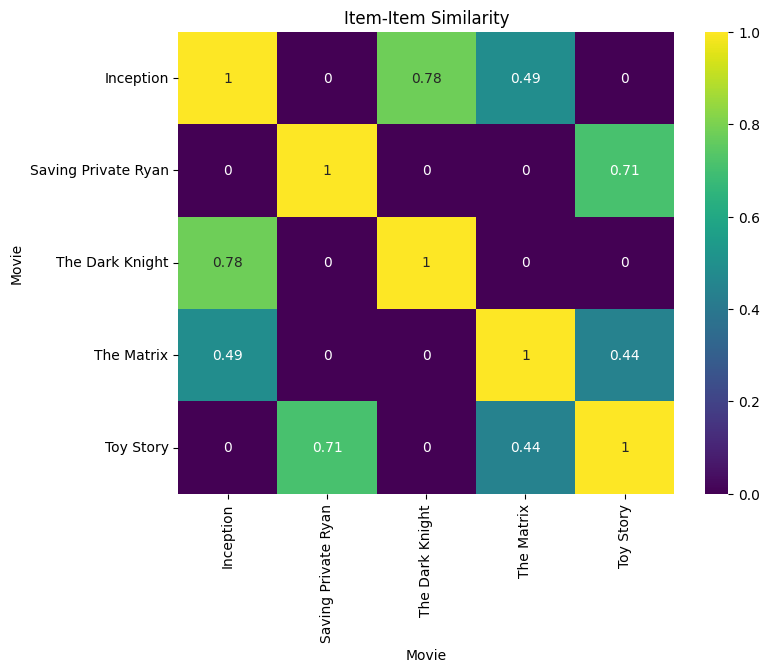

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(pd.DataFrame(item_similarity, index=ratings_matrix.columns, columns=ratings_matrix.columns), annot=True, cmap='viridis')
plt.title('Item-Item Similarity')
plt.show()